In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from MLP import MLP,train,test
from Gradcheck import GradientsChecker,check_grads,WarmupCosineSchedular
from Optimizer import Adam,RMSProp,SGD,AdamW
from sklearn.model_selection import train_test_split

In [2]:
data=pd.read_csv('clean.csv')

In [3]:
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,1.0
1,1,1,1,38.0,1,0,71.2833,2.0
2,1,3,1,26.0,0,0,7.9250,1.0
3,1,1,1,35.0,1,0,53.1000,1.0
4,0,3,0,35.0,0,0,8.0500,1.0


In [4]:
x=data.drop('Survived',axis=1)
y=data['Survived']

In [5]:
y=y.to_numpy().reshape(-1,1)

In [6]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [7]:
model=MLP(7,10,1)
optim=Adam(model)

In [ ]:
print("======LAUNCHING GRADEINTS CHECCKING========")
train_losses=[]
diff=GradientsChecker.check(model,x_train,y_train)
print(f"Relative Difference is :{diff}")
if diff<1e-7:
    print("succes :Every thing is correct")
elif diff<1e-4:
    print("Wrong :Minor precision")
else:
    print("Fianal Error : Check your implementation line by line")
epochs=int(input("How many epochs you want to train your model :"))
for epoch in range(epochs):
    y_pred=model.forward(x_train)
    loss=model.compute_loss(y_pred,y_train)
    train_losses.append(loss)
    model.backward(y_train)
    optim.step()

    if epoch %100==0:
        print(f"epoch :{epoch}   | Loss :{loss}")

In [ ]:
test_losses=[]
for epoch in range(len(x_test)):
    pred=model.forward(x_test)
    test_loss=model.compute_loss(pred,y_test)
    test_losses.append(test_loss)
    prediction=np.mean(pred>=0.5).astype(int)
    acc=np.mean(prediction==y_test)

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(train_losses,label="Adam Training Loss")
plt.plot(test_losses,label="Adam test loss",c='r')
plt.xlabel("epochs")
plt.ylabel("Loss")
plt.title("Loss curve ")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
model2=MLP(7,10,1)
optimizer=AdamW(model2)

In [ ]:
print("======LAUNCHING GRADEINTS CHECCKING========")
train_losses2=[]
diff2=GradientsChecker.check(model2,x_train,y_train)
print(f"Relative Difference is :{diff2}")
if diff<1e-7:
    print("succes :Every thing is correct")
elif diff<1e-4:
    print("Wrong :Minor precision")
else:
    print("Fianal Error : Check your implementation line by line")
epochs=int(input("How many epochs you want to train your model :"))
for epoch in range(epochs):
    y_pred=model2.forward(x_train)
    loss2=model2.compute_loss(y_pred,y_train)
    train_losses2.append(loss2)
    model2.backward(y_train)
    optimizer.step()

    if epoch %100==0:
        print(f"epoch :{epoch}   | Loss :{loss}")

In [ ]:
test_losses2=[]
for epoch in range(len(x_test)):
    pred2=model2.forward(x_test)
    test_loss2=model2.compute_loss(pred2,y_test)
    test_losses2.append(test_loss2)
    prediction2=np.mean(pred>=0.5).astype(int)
    acc2=np.mean(prediction2==y_test)

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(train_losses2,label="AdamW Training Loss")
plt.plot(test_losses2,label="AdamW test loss",c='r')
plt.xlabel("epochs")
plt.ylabel("Loss")
plt.title("Loss curve ")
plt.grid(True)
plt.legend()
plt.show()

In [7]:
model3=MLP(7,10,1)
optim2=AdamW(model3)

In [8]:
total_epochs=10
batch_per_epoch=1000
total_steps=total_epochs*batch_per_epoch
WARMUP_STEPS=1000

schedular=WarmupCosineSchedular(peak_lr=1e-3,
                                warmup_steps=WARMUP_STEPS,
                                total_steps=total_steps,
                                min_lr=1e-5)


In [9]:
losses=train(model3,x_train,y_train,epochs=2000,optimizer=optim2)

Epoch 0  | Loss :  0.6886491947815868
Epoch 100  | Loss :  0.5996501026446441
Epoch 200  | Loss :  0.5513321759886853
Epoch 300  | Loss :  0.5304931832171818
Epoch 400  | Loss :  0.5106716376546256
Epoch 500  | Loss :  0.49492267389707056
Epoch 600  | Loss :  0.4801409156334818
Epoch 700  | Loss :  0.46656637111135535
Epoch 800  | Loss :  0.45278587313171276
Epoch 900  | Loss :  0.441775915031193
Epoch 1000  | Loss :  0.4332671007562828
Epoch 1100  | Loss :  0.4267611255296073
Epoch 1200  | Loss :  0.42146690616350396
Epoch 1300  | Loss :  0.4145904189720462
Epoch 1400  | Loss :  0.4097410484822944
Epoch 1500  | Loss :  0.4053602464803624
Epoch 1600  | Loss :  0.4013037007324476
Epoch 1700  | Loss :  0.3975277967251776
Epoch 1800  | Loss :  0.39392956030969606
Epoch 1900  | Loss :  0.3903348038278936


In [10]:
test_loses=test(model3,x_test,y_test)

Test Loss is :0.11151460159596531
Test Loss is :0.044179462693501405
Test Loss is :0.3874992047764772
Test Loss is :0.18801975163324267
Test Loss is :0.06116140338497088
Test Loss is :2.2318790414020966
Test Loss is :0.24899101495287937
Test Loss is :0.15712869047732084
Test Loss is :0.06380933638633286
Test Loss is :0.05961709713705221
Test Loss is :0.6789657690585159
Test Loss is :0.6991377052830628
Test Loss is :0.03318102798547698
Test Loss is :0.14059591589074563
Test Loss is :0.11292111269534659
Test Loss is :0.30917158638570147
Test Loss is :0.7627742338167428
Test Loss is :0.13534646011614204
Test Loss is :0.4076358923707159
Test Loss is :0.10312116193446952
Test Loss is :0.18429200251922162
Test Loss is :0.04710747838714173
Test Loss is :0.046061937670745165
Test Loss is :0.6316629641400537
Test Loss is :0.10363908321821291
Test Loss is :0.4798391165853843
Test Loss is :0.18876749343757382
Test Loss is :0.10891168964768809
Test Loss is :0.6820911271975294
Test Loss is :0.18691

In [16]:
test_loses=list(test_loses)

In [ ]:
shape

NameError: name 'shape' is not defined

ValueError: Input could not be cast to an at-least-1D NumPy array

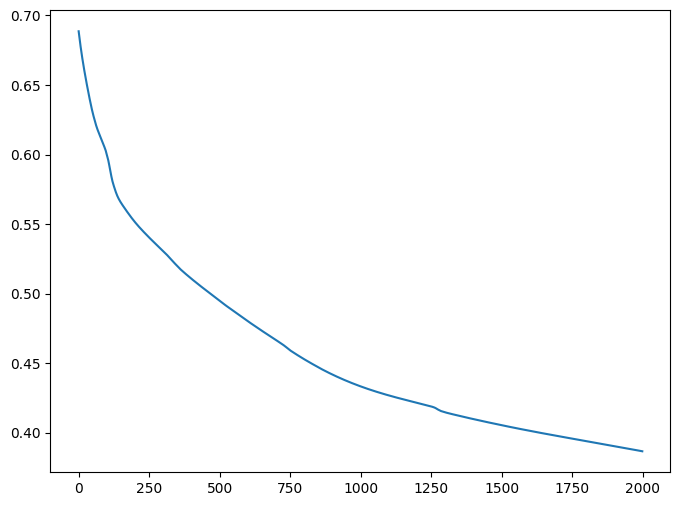

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.plot(losses)
plt.plot(test_loses)